In [1]:
import pandas as pd
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.load_ecg import load_ecg, load_ecg_with_metadata

## Load Afib Task Subset

In [2]:
afib = pd.read_parquet("../data/processed/afib_subset_metadata.parquet")

print(afib.shape)
afib.head()

(10000, 11)


,subject_id,study_id,file_name,ecg_time,path,machine_report,is_af,is_normal_strict,is_clearly_abnormal,waveform_path,label
0,10001860,45808859,45808859,2188-03-28 07:39:00,files/p1000/p10001860/s45808859/45808859,atrial fibrillation with slow ventricular resp...,True,False,False,../data/raw_waveforms/files/p1000/p10001860/s4...,1
1,10002157,41748669,41748669,2120-12-20 20:53:00,files/p1000/p10002157/s41748669/41748669,sinus rhythm | | normal ecg | | | | | | ...,False,True,False,../data/raw_waveforms/files/p1000/p10002157/s4...,0
2,10003400,45036862,45036862,2134-04-04 14:44:00,files/p1000/p10003400/s45036862/45036862,atrial fibrillation | leftward axis | qrs chan...,True,False,False,../data/raw_waveforms/files/p1000/p10003400/s4...,1
3,10003400,47684518,47684518,2137-03-01 21:49:00,files/p1000/p10003400/s47684518/47684518,atrial fibrillation with rapid ventricular res...,True,False,False,../data/raw_waveforms/files/p1000/p10003400/s4...,1
4,10003400,47771850,47771850,2137-03-17 05:13:00,files/p1000/p10003400/s47771850/47771850,atrial fibrillation with rapid ventricular res...,True,False,False,../data/raw_waveforms/files/p1000/p10003400/s4...,1


### Use ECG Loader

In [3]:
example_rel_path = afib.iloc[0]["path"]
example_full_path = f"../data/raw_waveforms/{example_rel_path}"

signal, fs, sig_names, units = load_ecg_with_metadata(example_full_path)

print("Shape:", signal.shape)
print("Sampling frequency:", fs)
print("Lead names:", sig_names)

Shape: (5000, 12)
Sampling frequency: 500
Lead names: ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


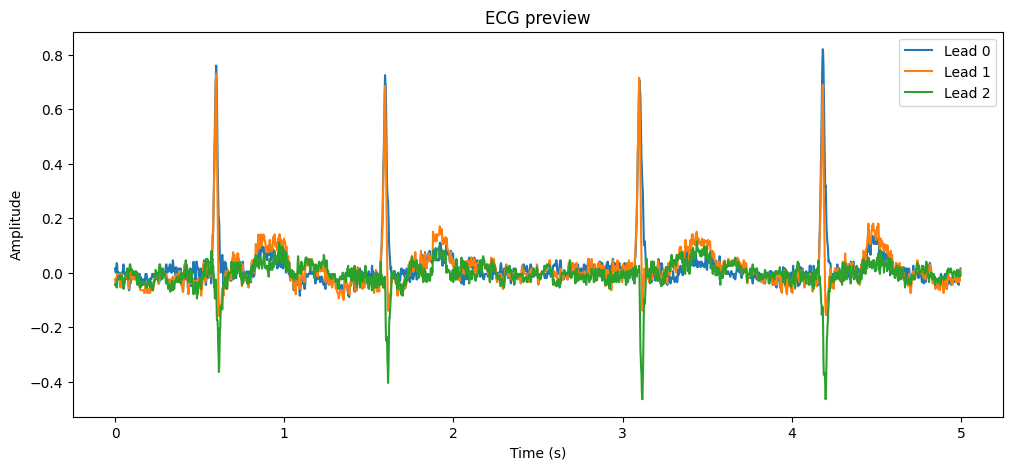

In [4]:
def plot_ecg(signal, fs, leads=[0,1,2], seconds=5):
    n_samples = min(len(signal), seconds * fs)
    t = np.arange(n_samples) / fs
    
    plt.figure(figsize=(12,5))
    
    for lead in leads:
        plt.plot(t, signal[:n_samples, lead], label=f"Lead {lead}")
        
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("ECG preview")
    plt.legend()
    plt.show()

plot_ecg(signal, fs)

## ECG Signal Processing
### Bandpass Filtering
Bandpass filtering with butterworth

In [5]:
import scipy.signal as sps


def bandpass_filter_ecg(signal, fs, low=0.5, high=40.0, order=4):
    """
    Bandpass filter a multi-lead ECG array of shape (n_samples, n_leads).
    """
    nyq = 0.5 * fs
    b, a = sps.butter(order, [low / nyq, high / nyq], btype="band")
    return sps.filtfilt(b, a, signal, axis=0)


def get_lead(signal, sig_names, lead_name="II"):
    """
    Extract one lead by name.
    """
    if lead_name not in sig_names:
        raise ValueError(f"Lead {lead_name} not found. Available leads: {sig_names}")
    idx = sig_names.index(lead_name)
    return signal[:, idx]

In [6]:
signal_filt = bandpass_filter_ecg(signal, fs)
lead2 = get_lead(signal_filt, sig_names, lead_name="II")

print("Filtered shape:", signal_filt.shape)
print("Lead II shape:", lead2.shape)
print("Lead II mean:", np.mean(lead2))
print("Lead II std:", np.std(lead2))

Filtered shape: (5000, 12)
Lead II shape: (5000,)
Lead II mean: -0.00039257601125022667
Lead II std: 0.08615371759499643


In [7]:
def plot_raw_vs_filtered(raw_signal, filt_signal, fs, sig_names, lead_name="II", seconds=5):
    raw_lead = get_lead(raw_signal, sig_names, lead_name)
    filt_lead = get_lead(filt_signal, sig_names, lead_name)

    n_samples = min(len(raw_lead), int(seconds * fs))
    t = np.arange(n_samples) / fs

    plt.figure(figsize=(12, 5))
    plt.plot(t, raw_lead[:n_samples], label=f"Raw {lead_name}", alpha=0.7)
    plt.plot(t, filt_lead[:n_samples], label=f"Filtered {lead_name}", alpha=0.9)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Raw vs Filtered ECG ({lead_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()

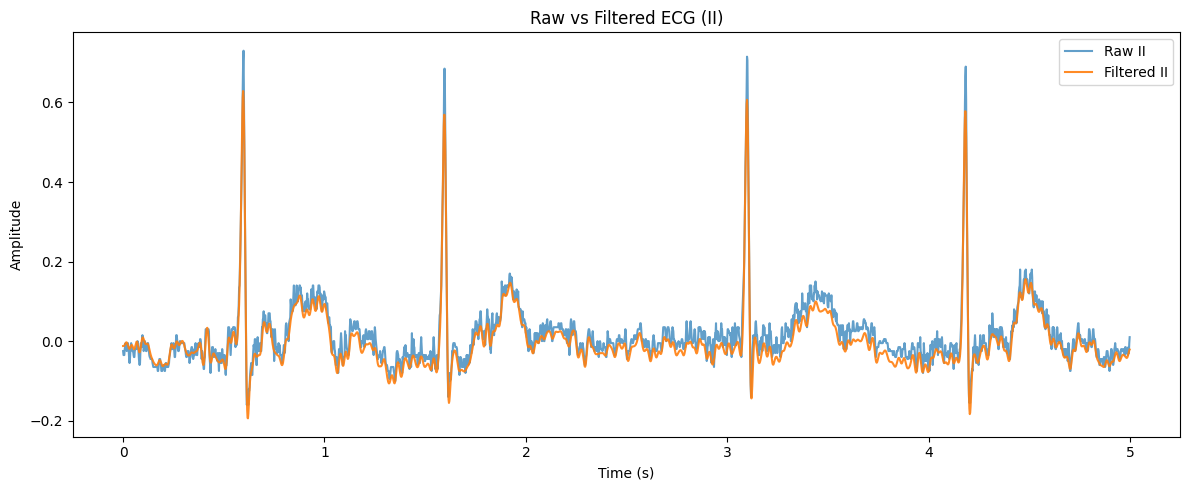

In [8]:
plot_raw_vs_filtered(signal, signal_filt, fs, sig_names, lead_name="II", seconds=5)

### R-Peak Detection
To analyze heart rhythm from ECG signals, the locations of ventricular depolarization events (R-peaks) must first be identified. R-peaks correspond to the highest amplitude component of the QRS complex and represent individual heartbeats.

R-peak detection was performed using Lead II, which is commonly used for rhythm analysis due to its clear visualization of the cardiac electrical axis. The ECG signal was first bandpass filtered between 5–20 Hz to emphasize QRS complexes and suppress baseline drift and high-frequency noise. The filtered signal was then squared to amplify large deflections associated with QRS complexes. A moving average integration window (~150 ms) was applied to smooth the signal and highlight candidate peak regions.

Candidate R-peaks were then identified using a peak detection algorithm with a minimum refractory period of 250 ms, preventing multiple detections within the same cardiac cycle. The detection threshold was set adaptively using a high percentile of the processed signal amplitude to focus on prominent peaks.

The resulting peak indices represent the estimated timing of individual heartbeats.

In [9]:
def detect_r_peaks_lead2(lead_signal, fs):
    """
    Simple R-peak detector for a single lead.
    """
    # emphasize QRS-like content
    qrs_band = bandpass_filter_ecg(lead_signal[:, None], fs, low=5.0, high=20.0, order=2).squeeze()

    squared = qrs_band ** 2

    win = max(1, int(0.15 * fs))  # ~150 ms
    kernel = np.ones(win) / win
    integrated = np.convolve(squared, kernel, mode="same")

    distance = int(0.25 * fs)  # refractory period: 250 ms
    height = np.percentile(integrated, 90)

    peaks, props = sps.find_peaks(integrated, distance=distance, height=height)
    return peaks, integrated

In [10]:
peaks, integrated = detect_r_peaks_lead2(lead2, fs)

print("Number of detected peaks:", len(peaks))
print("Peak indices:", peaks[:10])

Number of detected peaks: 9
Peak indices: [ 291  789 1546 2085 2604 3084 3600 4206 4766]


In [37]:
def plot_r_peaks(lead_signal, fs, peaks, seconds=5):
    n_samples = min(len(lead_signal), int(seconds * fs))
    t = np.arange(n_samples) / fs

    valid_peaks = peaks[peaks < n_samples]

    plt.figure(figsize=(10, 4))
    plt.plot(t, lead_signal[:n_samples], label="Lead II")
    plt.scatter(valid_peaks / fs, lead_signal[valid_peaks], color="red", label="Detected R-peaks")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Sample ECG Signal with R-peak Detection", fontsize=18)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig(
        PROJECT_ROOT / "results" / "figures" / "example_ecg_r_peak.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

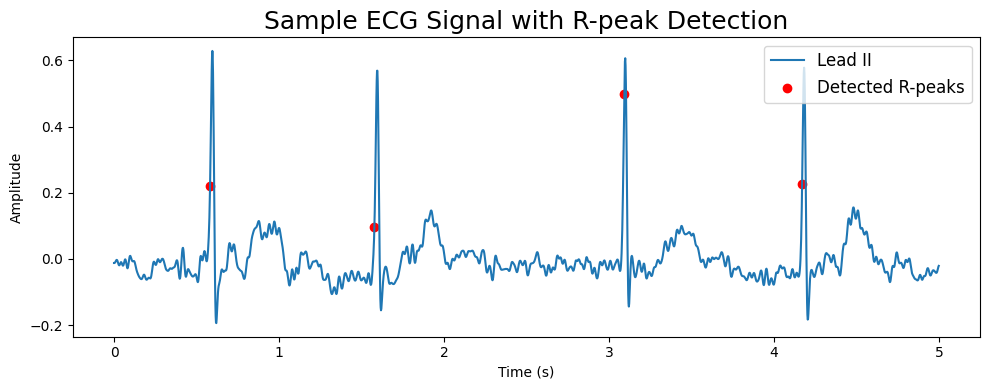

In [38]:
plot_r_peaks(lead2, fs, peaks, seconds=5)

### RR Interval Features
After identifying R-peaks, RR intervals were computed as the time differences between consecutive peaks. RR intervals represent the duration between successive heartbeats and provide important information about cardiac rhythm dynamics.

Several summary statistics were extracted from the RR interval sequence:
- **Number of R peaks:** This represents the number of detected heartbeats within the recording window.
- **Mean RR Interval:** The average time between heartbeats (where a heartbeat is a R peak)
- **RR Interval Standard Deviation:** The standard deviation of RR intervals measures variability in heartbeat timing. Increased variability can indicate irregular rhythms.
- **Root Mean Square of Successive Differences (RMSSD):** RMSSD quantifies beat-to-beat variability and is commonly used in heart rate variability analysis.
- **Estimated Heart Rate:** Heart rate was computed by dividing 60 by the mean RR interval. 

In [13]:
def compute_rr_features(peaks, fs):
    if len(peaks) < 2:
        return {
            "n_r_peaks": len(peaks),
            "rr_mean": np.nan,
            "rr_std": np.nan,
            "rmssd": np.nan,
            "heart_rate_bpm": np.nan,
        }

    rr = np.diff(peaks) / fs
    rr_diff = np.diff(rr)

    return {
        "n_r_peaks": len(peaks),
        "rr_mean": float(np.mean(rr)),
        "rr_std": float(np.std(rr)),
        "rmssd": float(np.sqrt(np.mean(rr_diff ** 2))) if len(rr_diff) > 0 else np.nan,
        "heart_rate_bpm": float(60.0 / np.mean(rr)) if np.mean(rr) > 0 else np.nan,
    }

In [14]:
rr_features = compute_rr_features(peaks, fs)
rr_features

{'n_r_peaks': 9,
 'rr_mean': 1.11875,
 'rr_std': 0.16616840102739147,
 'rmssd': 0.2704895033611682,
 'heart_rate_bpm': 53.631284916201125}

In [15]:
afib.iloc[0]['machine_report']

'atrial fibrillation with slow ventricular response | prolonged qt interval |  | abnormal ecg |  |  |  |  |  |  |  |  |  |  |  |  |  | '

### Time Domain Features
Time-domain features characterize the amplitude and variability of the ECG waveform directly in the time domain. These features summarize the basic statistical properties of the signal and capture differences in waveform morphology across recordings.

For each ECG lead, several summary statistics were computed, including the mean, standard deviation, minimum, maximum, root mean square (RMS) amplitude, peak to peak amplitude, and signal energy. The mean and standard deviation describe the central tendency and variability of the signal amplitude, while the minimum and maximum capture extreme waveform deflections. The peak-to-peak amplitude measures the difference between the largest positive and negative deflections of the signal, reflecting the magnitude of cardiac depolarization signals. RMS amplitude provides an estimate of the overall signal magnitude, and signal energy quantifies the total power contained in the waveform.

Because each ECG recording contains 12 leads, these features were computed separately for each lead and then aggregated across leads using summary statistics (mean, standard deviation, minimum, and maximum). Aggregating across leads provides a compact representation of overall waveform characteristics while preserving information about inter-lead variability.

In [16]:
from scipy.stats import entropy


def compute_rms(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.sqrt(np.mean(np.square(x))))


def compute_energy(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.sum(np.square(x)))


def compute_peak_to_peak(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.ptp(x))


def compute_basic_features(x, prefix="signal"):
    x = np.asarray(x, dtype=np.float64)

    return {
        f"{prefix}_mean": float(np.mean(x)),
        f"{prefix}_std": float(np.std(x)),
        f"{prefix}_min": float(np.min(x)),
        f"{prefix}_max": float(np.max(x)),
        f"{prefix}_ptp": compute_peak_to_peak(x),
        f"{prefix}_rms": compute_rms(x),
        f"{prefix}_energy": compute_energy(x),
    }

In [17]:
basic_feats = compute_basic_features(lead2, prefix="lead2")
basic_feats

{'lead2_mean': -0.00039257601125022667,
 'lead2_std': 0.08615371759499643,
 'lead2_min': -0.24699566838246442,
 'lead2_max': 0.6286523632146134,
 'lead2_ptp': 0.8756480315970778,
 'lead2_rms': 0.08615461201446505,
 'lead2_energy': 37.113085856815026}

### Spectral Features
Spectral features describe the frequency-domain structure of the ECG signal. While time-domain features capture waveform amplitude and variability, spectral analysis reveals how signal energy is distributed across frequencies.

The power spectral density (PSD) of each lead was estimated using Welch’s method, which provides a robust estimate of signal power across frequencies by averaging periodograms over overlapping windows. From the estimated PSD, several spectral features were computed.

The dominant frequency corresponds to the frequency with the highest power in the spectrum. This feature can capture periodic signal components associated with heart rhythm. The spectral centroid measures the center of mass of the power spectrum and represents the average frequency weighted by spectral power. The spectral entropy quantifies the complexity of the spectral distribution, measuring how evenly power is distributed across frequencies.

In addition, band power features were computed across several physiologically relevant frequency bands (0.5–5 Hz, 5–15 Hz, and 15–40 Hz). These bands capture different aspects of ECG morphology, including low-frequency baseline components and higher-frequency QRS activity. As with the time-domain features, spectral features were computed per lead and then aggregated across leads to produce global summary statistics.

In [18]:
def spectral_entropy(psd):
    psd = np.asarray(psd, dtype=np.float64)
    psd_sum = psd.sum()
    if psd_sum <= 0:
        return np.nan
    p = psd / psd_sum
    return float(entropy(p))


def spectral_centroid(freqs, psd):
    freqs = np.asarray(freqs, dtype=np.float64)
    psd = np.asarray(psd, dtype=np.float64)

    denom = np.sum(psd)
    if denom <= 0:
        return np.nan

    return float(np.sum(freqs * psd) / denom)


def bandpower(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs < fmax)
    if not np.any(mask):
        return np.nan
    return float(np.trapezoid(psd[mask], freqs[mask]))


def compute_spectral_features(x, fs, prefix="signal"):
    x = np.asarray(x, dtype=np.float64)

    freqs, psd = sps.welch(x, fs=fs, nperseg=min(1024, len(x)))

    if len(psd) == 0 or np.all(psd == 0):
        return {
            f"{prefix}_dom_freq": np.nan,
            f"{prefix}_spec_entropy": np.nan,
            f"{prefix}_spec_centroid": np.nan,
            f"{prefix}_bp_0_5_5": np.nan,
            f"{prefix}_bp_5_15": np.nan,
            f"{prefix}_bp_15_40": np.nan,
        }

    return {
        f"{prefix}_dom_freq": float(freqs[np.argmax(psd)]),
        f"{prefix}_spec_entropy": spectral_entropy(psd),
        f"{prefix}_spec_centroid": spectral_centroid(freqs, psd),
        f"{prefix}_bp_0_5_5": bandpower(freqs, psd, 0.5, 5.0),
        f"{prefix}_bp_5_15": bandpower(freqs, psd, 5.0, 15.0),
        f"{prefix}_bp_15_40": bandpower(freqs, psd, 15.0, 40.0),
    }

In [19]:
spectral_feats = compute_spectral_features(lead2, fs, prefix="lead2")
spectral_feats

{'lead2_dom_freq': 0.9765625,
 'lead2_spec_entropy': 3.9746549819108288,
 'lead2_spec_centroid': 10.838981684445333,
 'lead2_bp_0_5_5': 0.0018892311670826957,
 'lead2_bp_5_15': 0.003040474145514691,
 'lead2_bp_15_40': 0.002416179265054347}

In [20]:
def plot_psd(x, fs, title="Power Spectral Density"):
    freqs, psd = sps.welch(x, fs=fs, nperseg=min(1024, len(x)))

    plt.figure(figsize=(10, 4))
    plt.plot(freqs, psd)
    plt.xlim(0, 40)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD")
    plt.title(title)
    plt.tight_layout()
    plt.show()

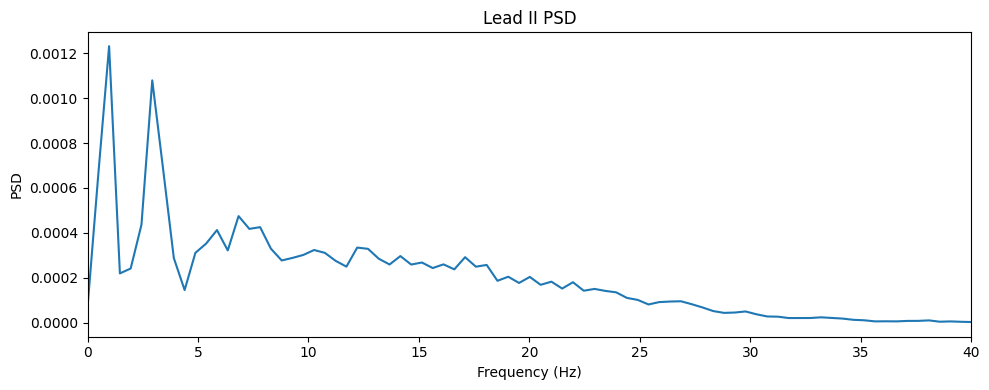

In [21]:
plot_psd(lead2, fs, title="Lead II PSD")

### Hjorth Parameters
Hjorth parameters are measures of signal complexity and dynamic behavior originally developed for EEG analysis but also applicable to other physiological signals such as ECG.

Three Hjorth parameters were computed from the ECG waveform: activity, mobility, and complexity.

Hjorth activity represents the variance of the signal and reflects the overall amplitude variability of the waveform. Hjorth mobility measures the standard deviation of the signal’s first derivative relative to the signal variance and can be interpreted as an estimate of the signal’s mean frequency. Hjorth complexity quantifies the change in signal frequency by comparing the mobility of the first derivative to that of the original signal.

In [22]:
def hjorth_parameters(x):
    x = np.asarray(x, dtype=np.float64)

    dx = np.diff(x)
    ddx = np.diff(dx)

    var_x = np.var(x)
    var_dx = np.var(dx) if len(dx) > 0 else np.nan
    var_ddx = np.var(ddx) if len(ddx) > 0 else np.nan

    activity = float(var_x)

    if var_x <= 0 or np.isnan(var_dx):
        return {
            "hjorth_activity": activity,
            "hjorth_mobility": np.nan,
            "hjorth_complexity": np.nan,
        }

    mobility = float(np.sqrt(var_dx / var_x))

    if var_dx <= 0 or np.isnan(var_ddx) or mobility <= 0:
        return {
            "hjorth_activity": activity,
            "hjorth_mobility": mobility,
            "hjorth_complexity": np.nan,
        }

    complexity = float(np.sqrt(var_ddx / var_dx) / mobility)

    return {
        "hjorth_activity": activity,
        "hjorth_mobility": mobility,
        "hjorth_complexity": complexity,
    }

In [23]:
hjorth_feats = hjorth_parameters(lead2)
hjorth_feats

{'hjorth_activity': 0.007422463055438397,
 'hjorth_mobility': 0.16633095033814063,
 'hjorth_complexity': 1.6932987541177145}

### Creating Combined Feature Vector

In [24]:
lead2_feature_dict = {}
lead2_feature_dict.update(compute_basic_features(lead2, prefix="lead2"))
lead2_feature_dict.update(compute_spectral_features(lead2, fs, prefix="lead2"))
lead2_feature_dict.update(hjorth_parameters(lead2))
lead2_feature_dict.update(rr_features)

lead2_feature_dict

{'lead2_mean': -0.00039257601125022667,
 'lead2_std': 0.08615371759499643,
 'lead2_min': -0.24699566838246442,
 'lead2_max': 0.6286523632146134,
 'lead2_ptp': 0.8756480315970778,
 'lead2_rms': 0.08615461201446505,
 'lead2_energy': 37.113085856815026,
 'lead2_dom_freq': 0.9765625,
 'lead2_spec_entropy': 3.9746549819108288,
 'lead2_spec_centroid': 10.838981684445333,
 'lead2_bp_0_5_5': 0.0018892311670826957,
 'lead2_bp_5_15': 0.003040474145514691,
 'lead2_bp_15_40': 0.002416179265054347,
 'hjorth_activity': 0.007422463055438397,
 'hjorth_mobility': 0.16633095033814063,
 'hjorth_complexity': 1.6932987541177145,
 'n_r_peaks': 9,
 'rr_mean': 1.11875,
 'rr_std': 0.16616840102739147,
 'rmssd': 0.2704895033611682,
 'heart_rate_bpm': 53.631284916201125}

### Reproduce For All 12 Leads

In [25]:
def aggregate_lead_features(values, prefix):
    values = np.asarray(values, dtype=np.float64)

    return {
        f"{prefix}_mean": float(np.nanmean(values)),
        f"{prefix}_std": float(np.nanstd(values)),
        f"{prefix}_min": float(np.nanmin(values)),
        f"{prefix}_max": float(np.nanmax(values)),
    }

In [26]:
aggregate_lead_features([1, 2, 3, 4], "test_feature")

{'test_feature_mean': 2.5,
 'test_feature_std': 1.118033988749895,
 'test_feature_min': 1.0,
 'test_feature_max': 4.0}

In [27]:
def compute_multilead_basic_features(ecg_signal):
    """
    ecg_signal shape: (n_samples, n_leads)
    Returns aggregated time-domain features across leads.
    """
    lead_means = []
    lead_stds = []
    lead_mins = []
    lead_maxs = []
    lead_ptp = []
    lead_rms = []
    lead_energy = []

    for i in range(ecg_signal.shape[1]):
        x = ecg_signal[:, i]

        lead_means.append(np.mean(x))
        lead_stds.append(np.std(x))
        lead_mins.append(np.min(x))
        lead_maxs.append(np.max(x))
        lead_ptp.append(compute_peak_to_peak(x))
        lead_rms.append(compute_rms(x))
        lead_energy.append(compute_energy(x))

    features = {}
    features.update(aggregate_lead_features(lead_means, "lead_mean"))
    features.update(aggregate_lead_features(lead_stds, "lead_std"))
    features.update(aggregate_lead_features(lead_mins, "lead_min"))
    features.update(aggregate_lead_features(lead_maxs, "lead_max"))
    features.update(aggregate_lead_features(lead_ptp, "lead_ptp"))
    features.update(aggregate_lead_features(lead_rms, "lead_rms"))
    features.update(aggregate_lead_features(lead_energy, "lead_energy"))

    return features

In [28]:
multilead_basic = compute_multilead_basic_features(signal_filt)
len(multilead_basic), multilead_basic

(28,
 {'lead_mean_mean': -0.0004411153557179995,
  'lead_mean_std': 0.00048822792368038553,
  'lead_mean_min': -0.0010722095291963549,
  'lead_mean_max': 0.00043394352627412037,
  'lead_std_mean': 0.12886221263140465,
  'lead_std_std': 0.05888081029680267,
  'lead_std_min': 0.05417348459124553,
  'lead_std_max': 0.2373512861759467,
  'lead_min_mean': -0.5730144321575391,
  'lead_min_std': 0.4604241738793789,
  'lead_min_min': -1.4303500852821691,
  'lead_min_max': -0.060789435563780615,
  'lead_max_mean': 0.6550722196567428,
  'lead_max_std': 0.560555436168012,
  'lead_max_min': 0.09540482839639917,
  'lead_max_max': 1.9188746751982857,
  'lead_ptp_mean': 1.228086651814282,
  'lead_ptp_std': 0.6156005549546654,
  'lead_ptp_min': 0.5735900368448372,
  'lead_ptp_max': 2.639571617696015,
  'lead_rms_mean': 0.12886359121222674,
  'lead_rms_std': 0.05888146970499328,
  'lead_rms_min': 0.05417359795355703,
  'lead_rms_max': 0.23735343160461717,
  'lead_energy_mean': 100.36426307365959,
  'le

In [29]:
def compute_multilead_spectral_features(ecg_signal, fs):
    """
    ecg_signal shape: (n_samples, n_leads)
    Returns aggregated spectral features across leads.
    """
    dom_freqs = []
    spec_entropies = []
    spec_centroids = []
    bp_low = []
    bp_mid = []
    bp_high = []

    for i in range(ecg_signal.shape[1]):
        x = ecg_signal[:, i]
        feats = compute_spectral_features(x, fs, prefix=f"lead{i}")

        dom_freqs.append(feats[f"lead{i}_dom_freq"])
        spec_entropies.append(feats[f"lead{i}_spec_entropy"])
        spec_centroids.append(feats[f"lead{i}_spec_centroid"])
        bp_low.append(feats[f"lead{i}_bp_0_5_5"])
        bp_mid.append(feats[f"lead{i}_bp_5_15"])
        bp_high.append(feats[f"lead{i}_bp_15_40"])

    features = {}
    features.update(aggregate_lead_features(dom_freqs, "dom_freq"))
    features.update(aggregate_lead_features(spec_entropies, "spec_entropy"))
    features.update(aggregate_lead_features(spec_centroids, "spec_centroid"))
    features.update(aggregate_lead_features(bp_low, "bp_0_5_5"))
    features.update(aggregate_lead_features(bp_mid, "bp_5_15"))
    features.update(aggregate_lead_features(bp_high, "bp_15_40"))

    return features

In [30]:
multilead_spectral = compute_multilead_spectral_features(signal_filt, fs)
len(multilead_spectral), multilead_spectral

(24,
 {'dom_freq_mean': 1.7903645833333333,
  'dom_freq_std': 0.9629036105305365,
  'dom_freq_min': 0.9765625,
  'dom_freq_max': 2.9296875,
  'spec_entropy_mean': 3.827519953675338,
  'spec_entropy_std': 0.1687104410227822,
  'spec_entropy_min': 3.5408338269589277,
  'spec_entropy_max': 4.067760701948499,
  'spec_centroid_mean': 9.435930109779163,
  'spec_centroid_std': 1.8634480015972474,
  'spec_centroid_min': 6.7848053580476035,
  'spec_centroid_max': 12.30219792436367,
  'bp_0_5_5_mean': 0.006081899233061159,
  'bp_0_5_5_std': 0.004665983144764858,
  'bp_0_5_5_min': 0.0006164013520884598,
  'bp_0_5_5_max': 0.01359080326939448,
  'bp_5_15_mean': 0.010010426546103655,
  'bp_5_15_std': 0.008192153148838427,
  'bp_5_15_min': 0.001051047447360851,
  'bp_5_15_max': 0.026990010134614422,
  'bp_15_40_mean': 0.0051903021721663245,
  'bp_15_40_std': 0.006260824518706657,
  'bp_15_40_min': 0.0004566229332026854,
  'bp_15_40_max': 0.022750571697490927})

In [31]:
def extract_ecg_features_notebook(signal, fs, sig_names):
    """
    Extract a full handcrafted feature vector from one 12-lead ECG.
    """
    # Step 1: filter ECG
    signal_filt = bandpass_filter_ecg(signal, fs)

    features = {}

    # Step 2: multilead time-domain features
    features.update(compute_multilead_basic_features(signal_filt))

    # Step 3: multilead spectral features
    features.update(compute_multilead_spectral_features(signal_filt, fs))

    # Step 4: Lead II rhythm + complexity features
    lead2 = get_lead(signal_filt, sig_names, lead_name="II")

    peaks, integrated = detect_r_peaks_lead2(lead2, fs)
    rr_features = compute_rr_features(peaks, fs)

    rr = np.diff(peaks) / fs if len(peaks) >= 2 else np.array([])
    rr_range = float(np.max(rr) - np.min(rr)) if len(rr) > 0 else np.nan

    hjorth_feats = hjorth_parameters(lead2)

    features.update(hjorth_feats)
    features.update(rr_features)
    features["rr_range"] = rr_range

    return features

In [32]:
ecg_features = extract_ecg_features_notebook(signal, fs, sig_names)

print("Number of features:", len(ecg_features))
list(ecg_features.items())[:10]

Number of features: 61


[('lead_mean_mean', -0.0004411153557179995),
 ('lead_mean_std', 0.00048822792368038553),
 ('lead_mean_min', -0.0010722095291963549),
 ('lead_mean_max', 0.00043394352627412037),
 ('lead_std_mean', 0.12886221263140465),
 ('lead_std_std', 0.05888081029680267),
 ('lead_std_min', 0.05417348459124553),
 ('lead_std_max', 0.2373512861759467),
 ('lead_min_mean', -0.5730144321575391),
 ('lead_min_std', 0.4604241738793789)]

In [33]:
for k, v in ecg_features.items():
    print(f"{k}: {v}")

lead_mean_mean: -0.0004411153557179995
lead_mean_std: 0.00048822792368038553
lead_mean_min: -0.0010722095291963549
lead_mean_max: 0.00043394352627412037
lead_std_mean: 0.12886221263140465
lead_std_std: 0.05888081029680267
lead_std_min: 0.05417348459124553
lead_std_max: 0.2373512861759467
lead_min_mean: -0.5730144321575391
lead_min_std: 0.4604241738793789
lead_min_min: -1.4303500852821691
lead_min_max: -0.060789435563780615
lead_max_mean: 0.6550722196567428
lead_max_std: 0.560555436168012
lead_max_min: 0.09540482839639917
lead_max_max: 1.9188746751982857
lead_ptp_mean: 1.228086651814282
lead_ptp_std: 0.6156005549546654
lead_ptp_min: 0.5735900368448372
lead_ptp_max: 2.639571617696015
lead_rms_mean: 0.12886359121222674
lead_rms_std: 0.05888146970499328
lead_rms_min: 0.05417359795355703
lead_rms_max: 0.23735343160461717
lead_energy_mean: 100.36426307365959
lead_energy_std: 81.4796188878856
lead_energy_min: 14.673893576168194
lead_energy_max: 281.68325747243836
dom_freq_mean: 1.790364583333

In [34]:
one_row_df = pd.DataFrame([ecg_features])
one_row_df.head()

,lead_mean_mean,lead_mean_std,lead_mean_min,lead_mean_max,lead_std_mean,lead_std_std,lead_std_min,lead_std_max,lead_min_mean,lead_min_std,...,bp_15_40_max,hjorth_activity,hjorth_mobility,hjorth_complexity,n_r_peaks,rr_mean,rr_std,rmssd,heart_rate_bpm,rr_range
0,-0.000441,0.000488,-0.001072,0.000434,0.128862,0.058881,0.054173,0.237351,-0.573014,0.460424,...,0.022751,0.007422,0.166331,1.693299,9,1.11875,0.166168,0.27049,53.631285,0.554


## Batch Processing Pipeline Development

In [35]:
afib = pd.read_parquet("../data/processed/afib_subset_metadata.parquet")
norm = pd.read_parquet("../data/processed/norm_subset_metadata.parquet")

debug_batch = pd.concat([
    afib[afib["label"] == 1].sample(5, random_state=42),
    afib[afib["label"] == 0].sample(5, random_state=42),
]).reset_index(drop=True)

debug_batch[["subject_id", "study_id", "waveform_path", "label"]]

,subject_id,study_id,waveform_path,label
0,12888412,47671654,../data/raw_waveforms/files/p1288/p12888412/s4...,1
1,15218179,40431176,../data/raw_waveforms/files/p1521/p15218179/s4...,1
2,15360986,40234172,../data/raw_waveforms/files/p1536/p15360986/s4...,1
3,12018901,48550179,../data/raw_waveforms/files/p1201/p12018901/s4...,1
4,11369587,48037769,../data/raw_waveforms/files/p1136/p11369587/s4...,1
5,13030716,47316219,../data/raw_waveforms/files/p1303/p13030716/s4...,0
6,15151299,49567592,../data/raw_waveforms/files/p1515/p15151299/s4...,0
7,15279517,46008636,../data/raw_waveforms/files/p1527/p15279517/s4...,0
8,12177177,43513269,../data/raw_waveforms/files/p1217/p12177177/s4...,0
9,11469391,47762001,../data/raw_waveforms/files/p1146/p11469391/s4...,0


In [36]:
def get_waveform_path(row):
    return row["waveform_path"]

def process_ecg_row(row):
    waveform_path = get_waveform_path(row)

    signal, fs, sig_names, units = load_ecg_with_metadata(waveform_path)
    features = extract_ecg_features_notebook(signal, fs, sig_names)
    features['signal_length'] = len(signal)

    output = {
        "subject_id": row["subject_id"],
        "study_id": row["study_id"],
        "path": row["path"],
        "waveform_path": row["waveform_path"],
        "label": row["label"],
    }
    output.update(features)

    return output

In [37]:
one_result = process_ecg_row(debug_batch.iloc[0])
list(one_result.items())[:10]

[('subject_id', np.int64(12888412)),
 ('study_id', np.int64(47671654)),
 ('path', 'files/p1288/p12888412/s47671654/47671654'),
 ('waveform_path',
  '../data/raw_waveforms/files/p1288/p12888412/s47671654/47671654'),
 ('label', np.int64(1)),
 ('lead_mean_mean', -0.0012804888702193599),
 ('lead_mean_std', 0.0021813583550752682),
 ('lead_mean_min', -0.008070255933190265),
 ('lead_mean_max', 0.000966504218692511),
 ('lead_std_mean', 0.07669202097607235)]

In [38]:
print("Number of features:", len(one_result))

Number of features: 67


In [39]:
results = []
errors = []

for idx, row in debug_batch.iterrows():
    try:
        results.append(process_ecg_row(row))
        print(f"Processed {idx+1}/{len(debug_batch)}")
    except Exception as e:
        errors.append((idx, str(e)))

features_df = pd.DataFrame(results)

Processed 1/10
Processed 2/10
Processed 3/10
Processed 4/10
Processed 5/10
Processed 6/10
Processed 7/10
Processed 8/10
Processed 9/10
Processed 10/10


In [40]:
features_df.nunique().sort_values().head(10)

signal_length        1
label                2
n_r_peaks            5
dom_freq_min         5
dom_freq_max         8
dom_freq_std         9
dom_freq_mean        9
lead_mean_min       10
spec_entropy_min    10
spec_entropy_max    10
dtype: int64

### Make Pipeline Parallel

In [41]:
from joblib import Parallel, delayed
import os

In [42]:
def process_ecg_row_safe(row):
    try:
        result = process_ecg_row(row)
        return {
            "ok": True,
            "result": result
        }
    except Exception as e:
        return {
            "ok": False,
            "error": {
                "subject_id": row.get("subject_id", None),
                "study_id": row.get("study_id", None),
                "waveform_path": row.get("waveform_path", None),
                "label": row.get("label", None),
                "error": str(e),
            }
        }

test_out = process_ecg_row_safe(debug_batch.iloc[0])
test_out["ok"], list(test_out.keys())

(True, ['ok', 'result'])

In [43]:
N_JOBS = max(1, os.cpu_count() // 2)
N_JOBS

5

In [44]:
parallel_outputs = Parallel(n_jobs=N_JOBS, backend="loky", verbose=10)(
    delayed(process_ecg_row_safe)(row)
    for _, row in debug_batch.iterrows()
)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   3 out of  10 | elapsed:    0.9s remaining:    2.0s
[Parallel(n_jobs=5)]: Done   5 out of  10 | elapsed:    0.9s remaining:    0.9s
[Parallel(n_jobs=5)]: Done   7 out of  10 | elapsed:    0.9s remaining:    0.4s
[Parallel(n_jobs=5)]: Done  10 out of  10 | elapsed:    0.9s finished


In [45]:
results = [x["result"] for x in parallel_outputs if x["ok"]]
errors = [x["error"] for x in parallel_outputs if not x["ok"]]

features_df = pd.DataFrame(results)
errors_df = pd.DataFrame(errors)

print("Successful rows:", len(features_df))
print("Errored rows:", len(errors_df))
features_df.head()

Successful rows: 10
Errored rows: 0


,subject_id,study_id,path,waveform_path,label,lead_mean_mean,lead_mean_std,lead_mean_min,lead_mean_max,lead_std_mean,...,hjorth_activity,hjorth_mobility,hjorth_complexity,n_r_peaks,rr_mean,rr_std,rmssd,heart_rate_bpm,rr_range,signal_length
0,12888412,47671654,files/p1288/p12888412/s47671654/47671654,../data/raw_waveforms/files/p1288/p12888412/s4...,1,-0.001280,0.002181,-0.008070,0.000967,0.076692,...,0.006356,0.131355,1.971361,11,0.955000,0.401728,0.652011,62.827225,1.322,5000
1,15218179,40431176,files/p1521/p15218179/s40431176/40431176,../data/raw_waveforms/files/p1521/p15218179/s4...,1,0.000142,0.000372,-0.000446,0.000755,0.115694,...,0.006535,0.152394,1.632484,11,0.786600,0.138353,0.202667,76.277651,0.406,5000
2,15360986,40234172,files/p1536/p15360986/s40234172/40234172,../data/raw_waveforms/files/p1536/p15360986/s4...,1,0.000108,0.000538,-0.000676,0.000786,0.158877,...,0.019798,0.100367,2.322710,11,0.867000,0.527467,1.019109,69.204152,1.272,5000
3,12018901,48550179,files/p1201/p12018901/s48550179/48550179,../data/raw_waveforms/files/p1201/p12018901/s4...,1,0.000301,0.001384,-0.002076,0.002442,0.155369,...,0.024703,0.159873,1.455639,12,0.800909,0.334518,0.549018,74.914869,1.134,5000
4,11369587,48037769,files/p1136/p11369587/s48037769/48037769,../data/raw_waveforms/files/p1136/p11369587/s4...,1,-0.000433,0.000740,-0.002239,0.000182,0.234069,...,0.038161,0.049482,4.151539,7,1.248000,0.686898,1.101323,48.076923,1.918,5000


In [46]:
print(features_df.shape)
print(features_df["label"].value_counts())

features_df[[
    "study_id",
    "label",
    "heart_rate_bpm",
    "rr_mean",
    "rr_std",
    "rmssd",
    "rr_range"
]].head(10)

(10, 67)
label
1    5
0    5
Name: count, dtype: int64


,study_id,label,heart_rate_bpm,rr_mean,rr_std,rmssd,rr_range
0,47671654,1,62.827225,0.955000,0.401728,0.652011,1.322
1,40431176,1,76.277651,0.786600,0.138353,0.202667,0.406
2,40234172,1,69.204152,0.867000,0.527467,1.019109,1.272
3,48550179,1,74.914869,0.800909,0.334518,0.549018,1.134
4,48037769,1,48.076923,1.248000,0.686898,1.101323,1.918
5,47316219,0,90.458755,0.663286,0.017706,0.023317,0.074
6,49567592,0,73.025006,0.821636,0.258298,0.268706,0.924
7,46008636,0,73.349633,0.818000,0.267362,0.380525,0.710
8,43513269,0,69.502949,0.863273,0.014949,0.016935,0.050
9,47762001,0,76.923077,0.780000,0.020347,0.020609,0.072


In [47]:
features_df.isna().sum().sort_values(ascending=False).head(20)

subject_id            0
bp_5_15_std           0
dom_freq_max          0
spec_entropy_mean     0
spec_entropy_std      0
spec_entropy_min      0
spec_entropy_max      0
spec_centroid_mean    0
spec_centroid_std     0
spec_centroid_min     0
spec_centroid_max     0
bp_0_5_5_mean         0
bp_0_5_5_std          0
bp_0_5_5_min          0
bp_0_5_5_max          0
bp_5_15_mean          0
bp_5_15_min           0
dom_freq_std          0
bp_5_15_max           0
bp_15_40_mean         0
dtype: int64

#### Scale up

In [48]:
batch_100 = pd.concat([
    afib[afib["label"] == 1].sample(50, random_state=67),
    afib[afib["label"] == 0].sample(50, random_state=67),
]).reset_index(drop=True)

In [49]:
parallel_outputs_100 = Parallel(n_jobs=N_JOBS, backend="loky", verbose=10)(
    delayed(process_ecg_row_safe)(row)
    for _, row in batch_100.iterrows()
)

results_100 = [x["result"] for x in parallel_outputs_100 if x["ok"]]
errors_100 = [x["error"] for x in parallel_outputs_100 if not x["ok"]]

features_100_df = pd.DataFrame(results_100)
errors_100_df = pd.DataFrame(errors_100)

print("Successful rows:", len(features_100_df))
print("Errored rows:", len(errors_100_df))

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Batch computation too fast (0.03225111961364746s.) Setting batch_size=2.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=5)]: Batch computation too fast (0.0610349178314209s.) Setting batch_size=4.
[Parallel(n_jobs=5)]: Done  20 tasks      | elapsed:    0.1s
[Parallel(n_jobs=5)]: Batch computation too fast (0.05105423927307129s.) Setting batch_size=8.
[Parallel(n_jobs=5)]: Done  38 tasks      | elapsed:    0.2s


Successful rows: 100
Errored rows: 0


[Parallel(n_jobs=5)]: Done  68 tasks      | elapsed:    0.2s
[Parallel(n_jobs=5)]: Done  80 tasks      | elapsed:    0.3s
[Parallel(n_jobs=5)]: Done  91 tasks      | elapsed:    0.3s
[Parallel(n_jobs=5)]: Done 100 out of 100 | elapsed:    0.3s finished


## Final Parallel Processing Pipeline

In [50]:
def build_feature_table_parallel(df, n_jobs=4):
    outputs = Parallel(n_jobs=n_jobs, backend="loky", verbose=10)(
        delayed(process_ecg_row_safe)(row)
        for _, row in df.iterrows()
    )

    results = [x["result"] for x in outputs if x["ok"]]
    errors = [x["error"] for x in outputs if not x["ok"]]

    features_df = pd.DataFrame(results)
    errors_df = pd.DataFrame(errors)

    return features_df, errors_df

Use case:

### Afib Task Feature Table

In [51]:
features_af_df, errors_af_df = build_feature_table_parallel(
    afib,
    n_jobs=N_JOBS
)

print("AF features shape:", features_af_df.shape)
print("AF errors:", len(errors_af_df))

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Batch computation too fast (0.0295259952545166s.) Setting batch_size=2.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=5)]: Batch computation too fast (0.06221604347229004s.) Setting batch_size=4.
[Parallel(n_jobs=5)]: Done  20 tasks      | elapsed:    0.1s
[Parallel(n_jobs=5)]: Batch computation too fast (0.05058717727661133s.) Setting batch_size=8.
[Parallel(n_jobs=5)]: Done  38 tasks      | elapsed:    0.2s
[Parallel(n_jobs=5)]: Done  78 tasks      | elapsed:    0.3s
[Parallel(n_jobs=5)]: Batch computation too fast (0.12739992141723633s.) Setting batch_size=16.
[Parallel(n_jobs=5)]: Done 150 tasks      | elapsed:    0.4s
[Parallel(n_jobs=5)]: Done 326 tasks      | elapsed:    0.9s
[Parallel(n_jobs=5)]: Done 502 tasks      | elapsed:    1.2s
[Parallel(n_jobs=5)]: Done 710 tasks      | elapsed:    2

AF features shape: (10000, 67)
AF errors: 0


[Parallel(n_jobs=5)]: Done 10000 out of 10000 | elapsed:   19.9s finished


In [52]:
features_af_df.isna().sum().sort_values().tail(10)

lead_min_max         0
lead_ptp_mean        0
hjorth_activity      9
hjorth_mobility      9
hjorth_complexity    9
rr_mean              9
rr_std               9
rmssd                9
heart_rate_bpm       9
rr_range             9
dtype: int64

In [53]:
features_af_df[features_af_df['rr_mean'].isna()==True]['label'].value_counts()

label
1    6
0    3
Name: count, dtype: int64

In [54]:
null_ex = features_af_df[features_af_df['rr_mean'].isna()==True].iloc[0]

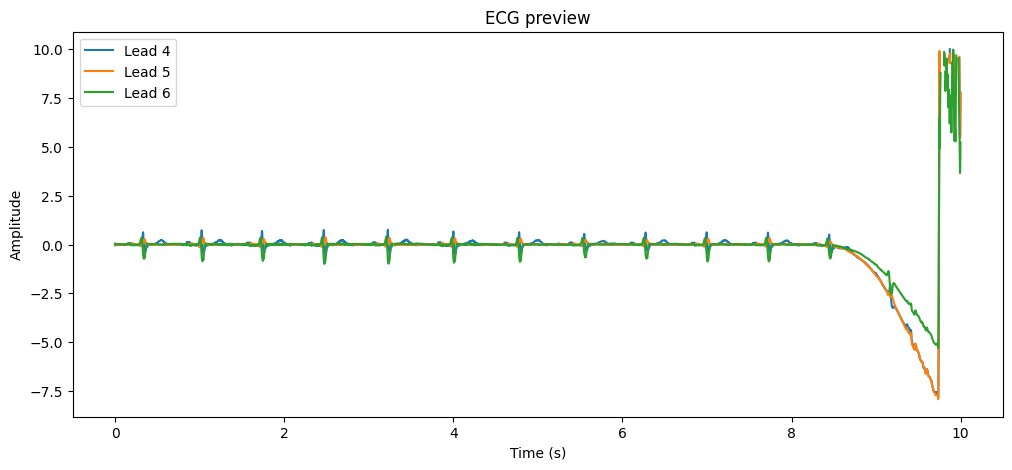

In [55]:
signal, fs, leads, _ = load_ecg_with_metadata(null_ex['waveform_path'])
plot_ecg(signal, fs, leads=[4, 5, 6], seconds=10)

### Abnormal Task Feature Table

In [56]:
features_norm_df, errors_norm_df = build_feature_table_parallel(
    norm,
    n_jobs=N_JOBS
)

print("Norm features shape:", features_norm_df.shape)
print("Norm errors:", len(errors_norm_df))

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Batch computation too fast (0.02365899085998535s.) Setting batch_size=2.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed:    0.1s
[Parallel(n_jobs=5)]: Batch computation too fast (0.0699760913848877s.) Setting batch_size=4.
[Parallel(n_jobs=5)]: Done  20 tasks      | elapsed:    0.1s
[Parallel(n_jobs=5)]: Batch computation too fast (0.04875302314758301s.) Setting batch_size=8.
[Parallel(n_jobs=5)]: Done  38 tasks      | elapsed:    0.2s
[Parallel(n_jobs=5)]: Done  78 tasks      | elapsed:    0.3s
[Parallel(n_jobs=5)]: Batch computation too fast (0.13098883628845215s.) Setting batch_size=16.
[Parallel(n_jobs=5)]: Done 150 tasks      | elapsed:    0.4s
[Parallel(n_jobs=5)]: Done 326 tasks      | elapsed:    0.8s
[Parallel(n_jobs=5)]: Done 502 tasks      | elapsed:    1.2s
[Parallel(n_jobs=5)]: Done 710 tasks      | elapsed:    1

Norm features shape: (10000, 67)
Norm errors: 0


[Parallel(n_jobs=5)]: Done 10000 out of 10000 | elapsed:   20.7s finished


In [57]:
features_norm_df.isna().sum().sort_values().tail(10)

lead_min_max          0
lead_ptp_mean         0
hjorth_activity      12
hjorth_mobility      12
hjorth_complexity    12
rr_mean              12
rr_std               12
rmssd                12
heart_rate_bpm       12
rr_range             12
dtype: int64

In [58]:
features_norm_df[features_norm_df['rr_mean'].isna()==True]['label'].value_counts()

label
1    9
0    3
Name: count, dtype: int64

In [59]:
features_norm_df[features_norm_df['rr_mean'].isna()==True]

,subject_id,study_id,path,waveform_path,label,lead_mean_mean,lead_mean_std,lead_mean_min,lead_mean_max,lead_std_mean,...,hjorth_activity,hjorth_mobility,hjorth_complexity,n_r_peaks,rr_mean,rr_std,rmssd,heart_rate_bpm,rr_range,signal_length
282,10286998,49448854,files/p1028/p10286998/s49448854/49448854,../data/raw_waveforms/files/p1028/p10286998/s4...,1,-0.000193,0.000288,-0.000659,0.000241,0.278144,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,5000
283,10286998,40070869,files/p1028/p10286998/s40070869/40070869,../data/raw_waveforms/files/p1028/p10286998/s4...,1,0.000133,0.000367,-0.000580,0.000792,0.258400,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,5000
532,10558918,41108408,files/p1055/p10558918/s41108408/41108408,../data/raw_waveforms/files/p1055/p10558918/s4...,1,-0.000030,0.000427,-0.000594,0.000557,0.241763,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,5000
3649,13572913,43509863,files/p1357/p13572913/s43509863/43509863,../data/raw_waveforms/files/p1357/p13572913/s4...,0,0.000488,0.000000,0.000488,0.000488,0.093344,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,5000
4899,14812210,47929745,files/p1481/p14812210/s47929745/47929745,../data/raw_waveforms/files/p1481/p14812210/s4...,1,-0.000971,0.001068,-0.002571,0.000941,0.330473,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,5000
5483,15389058,42342838,files/p1538/p15389058/s42342838/42342838,../data/raw_waveforms/files/p1538/p15389058/s4...,1,-0.005757,0.002511,-0.009075,-0.000201,0.312697,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,5000
7484,17462585,43850407,files/p1746/p17462585/s43850407/43850407,../data/raw_waveforms/files/p1746/p17462585/s4...,1,0.000115,0.000777,-0.000934,0.001248,0.396349,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,5000
7840,17828194,46738856,files/p1782/p17828194/s46738856/46738856,../data/raw_waveforms/files/p1782/p17828194/s4...,0,-0.000124,0.000107,-0.000270,0.000033,0.122132,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,5000
9009,18995174,42070173,files/p1899/p18995174/s42070173/42070173,../data/raw_waveforms/files/p1899/p18995174/s4...,1,0.000562,0.000000,0.000562,0.000562,0.150941,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,5000
9185,19182097,46151804,files/p1918/p19182097/s46151804/46151804,../data/raw_waveforms/files/p1918/p19182097/s4...,0,0.018279,0.007258,0.000814,0.027692,0.274474,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,5000


In [60]:
null_ex = features_norm_df[features_norm_df['rr_mean'].isna()==True].iloc[0]

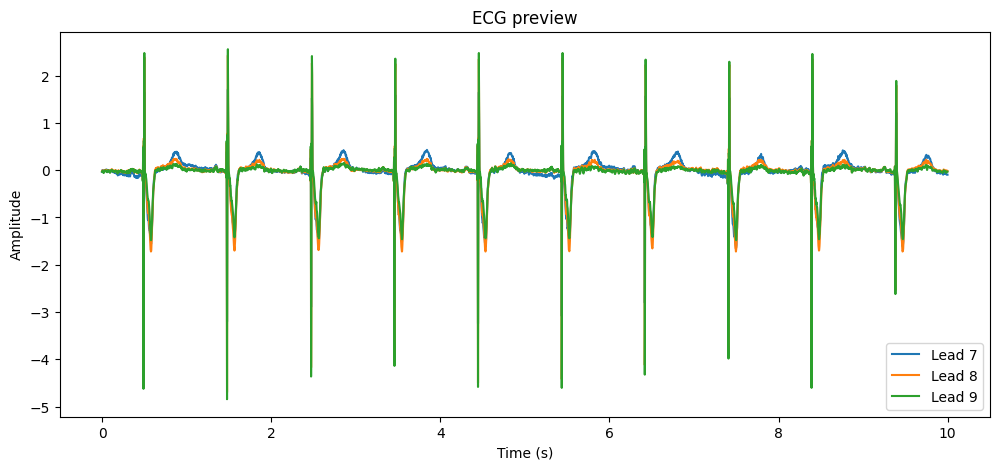

In [61]:
signal, fs, leads, _ = load_ecg_with_metadata(null_ex['waveform_path'])
plot_ecg(signal, fs, leads=[7, 8, 9], seconds=10)

#### Handling of ECG Recordings with Failed Rhythm Feature Extraction
During feature extraction, a small number of ECG recordings produced missing values in rhythm-derived features such as the mean RR interval, RR interval standard deviation, RMSSD, and estimated heart rate. These features depend on successful detection of R-peaks, which represent ventricular depolarization events in the ECG waveform. In rare cases, the R-peak detection algorithm failed to identify reliable peaks, resulting in undefined RR intervals.

Inspection of these recordings revealed that the failures were primarily caused by signal artifacts, including abrupt amplitude spikes or transient baseline shifts affecting individual leads. In some cases, the ECG signal contained narrow, high-amplitude impulses that were not physiologically plausible and likely resulted from electrode noise or recording artifacts. Because these impulses occurred over only one or two samples and were not consistently present across all leads, they did not represent true cardiac activity but could interfere with automated peak detection and rhythm analysis.

To ensure that all rhythm features were computed from physiologically meaningful signals, recordings with failed R-peak detection were excluded from the final dataset. These cases represented a very small fraction of the available data (<0.1% of recordings) and therefore had negligible impact on dataset size or class balance. Removing these recordings prevented corrupted signals from introducing undefined rhythm features into the feature matrix and ensured that downstream machine learning models were trained only on ECG recordings with valid morphological and rhythm information.

In [62]:
features_af_df = features_af_df.dropna(subset=["rr_mean"])

In [63]:
features_af_df.isna().sum().sort_values().tail(5)

lead_rms_max        0
lead_energy_mean    0
lead_energy_std     0
lead_min_max        0
signal_length       0
dtype: int64

In [64]:
print(features_af_df.shape)
features_af_df["label"].value_counts()

(9991, 67)


label
0    4997
1    4994
Name: count, dtype: int64

In [65]:
features_norm_df = features_norm_df.dropna(subset=['rr_mean'])

In [66]:
features_norm_df.isna().sum().sort_values().tail(5)

lead_rms_max        0
lead_energy_mean    0
lead_energy_std     0
lead_min_max        0
signal_length       0
dtype: int64

In [67]:
print(features_norm_df.shape)
features_norm_df["label"].value_counts()

(9988, 67)


label
0    4997
1    4991
Name: count, dtype: int64

In [69]:
features_af_df.to_parquet(
    "../data/processed/afib_subset_features.parquet",
    index=False
)
features_norm_df.to_parquet(
    "../data/processed/norm_subset_features.parquet",
    index=False
)